# Multivariate Variational Mode Decomposition (MVMD)

> **Original paper**: ur Rehman, N. & Aftab, H. (2019). *Multivariate Variational Mode Decomposition*. IEEE Transactions on Signal Processing, 67(23), 6039–6052.
> DOI: [10.1109/TSP.2019.2951223](https://doi.org/10.1109/TSP.2019.2951223)

This notebook introduces the motivation and mathematical foundations of MVMD, and reproduces key synthetic experiments from the paper using PySDKit.

---

## Contents

1. Motivation: from VMD to multivariate data
2. Multivariate modulated oscillations
3. Variational model and ADMM solution
4. Relation to channel-wise VMD
5. PySDKit API overview
6. Experiment 1: Mode alignment on a bivariate tone mixture
7. Experiment 2: Channel-wise VMD vs joint MVMD
8. Experiment 3: Noise robustness of mode alignment
9. Experiment 4: Quasi-orthogonality on white Gaussian noise
10. Experiment 5: PySDKit multivariate test signals
11. Summary


## 1. Motivation: from VMD to multivariate data

### 1.1 Why multivariate decomposition is hard

Many real-world recordings are **multichannel**: EEG/ECG arrays, fetal monitoring (FHR–UC), sensor networks, oceanographic trajectories, etc. For such data we typically need:

1. **Mode alignment** — similar frequency content should appear in the *same* mode index across channels;
2. Use of **cross-channel correlation** rather than treating channels as independent.

Classical linear transforms (STFT, wavelets) can be applied channel-wise, but they rely on fixed atoms and have limited joint time–frequency resolution. Fully data-driven multivariate methods such as **Multivariate EMD (MEMD)** operate in multidimensional space, yet inherit EMD’s empirical nature: sensitivity to noise/sampling, mode mixing across channels, and limited theoretical guarantees.

### 1.2 What MVMD contributes

Dragomiretskiy & Zosso’s **VMD** cast univariate decomposition as a constrained variational problem. MVMD extends that idea to $C$ channels:

- It models **multivariate modulated oscillations** that share a **common center frequency** $\omega_k$ across channels;
- The cost is the **sum of bandwidths of all modes across all channels**;
- Optimization uses the same ADMM structure and the **same user parameters** as univariate VMD (no extra knobs).

The paper emphasizes that this is *not* equivalent to running VMD independently on each channel: only a joint model enforces mode alignment through a shared $\omega_k$.


## 2. Multivariate modulated oscillations

### 2.1 Univariate AM–FM modes (reminder)

As in VMD / EMD, a univariate intrinsic mode is an AM–FM oscillation

$$
c_k(t)=a_k(t)\cos\big(\phi_k(t)\big),
\qquad
\omega_k(t)=\frac{\mathrm{d}\phi_k(t)}{\mathrm{d}t},
$$

with slowly varying amplitude and instantaneous frequency.

### 2.2 Joint / common frequency across channels

For a multichannel signal $\mathbf{x}(t)=[x_1(t),\ldots,x_C(t)]$, MVMD seeks modes

$$
\mathbf{u}_k(t)=\big[u_{k,1}(t),\ldots,u_{k,C}(t)\big]
$$

such that

$$
\mathbf{x}(t)=\sum_{k=1}^{K}\mathbf{u}_k(t).
$$

The key modeling assumption (paper Section IV) is that a **multivariate modulated oscillation** admits a **single joint instantaneous frequency** shared by all channels. In the variational model this appears as a **single center frequency** $\omega_k$ used for harmonic demodulation of *every* channel of mode $k$.

Intuition:

- A common tone present in several channels lands in one multivariate mode;
- A tone present in only one channel still occupies its own mode index, while other channels of that mode stay near zero;
- Channel-wise VMD can place the same physical frequency into different mode indices on different channels (**misalignment**).


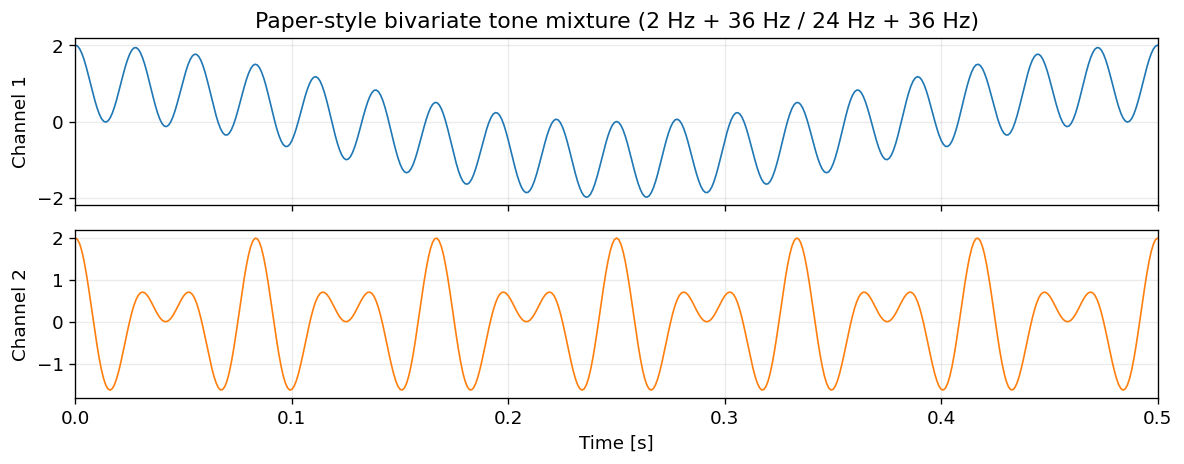

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from pysdkit import MVMD, VMD
from pysdkit.data import test_multivariate_signal

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "font.size": 11,
        "axes.grid": True,
        "grid.alpha": 0.25,
    }
)


def relative_error(ref, est):
    ref = np.asarray(ref, dtype=float)
    est = np.asarray(est, dtype=float)
    return np.linalg.norm(est - ref) / (np.linalg.norm(ref) + 1e-16)


def mode_energies(mode_kc):
    # Energy of each channel for one mode of shape (T, C).
    return np.sum(mode_kc**2, axis=0)


# Illustrate a bivariate mixture with one shared tone
fs = 1000.0
t = np.arange(0, 1.0, 1.0 / fs)
ch1 = np.cos(2 * np.pi * 2 * t) + np.cos(2 * np.pi * 36 * t)
ch2 = np.cos(2 * np.pi * 24 * t) + np.cos(2 * np.pi * 36 * t)

fig, axs = plt.subplots(2, 1, figsize=(10, 4), sharex=True)
axs[0].plot(t, ch1, lw=1.0)
axs[0].set_ylabel("Channel 1")
axs[0].set_title("Paper-style bivariate tone mixture (2 Hz + 36 Hz / 24 Hz + 36 Hz)")
axs[1].plot(t, ch2, lw=1.0, color="C1")
axs[1].set_ylabel("Channel 2")
axs[1].set_xlabel("Time [s]")
axs[1].set_xlim(0, 0.5)
plt.tight_layout()
plt.show()

## 3. Variational model and ADMM solution

### 3.1 Bandwidth cost for multichannel modes

Let $\mathbf{u}_{k}^{+}(t)$ be the vector analytic signal of mode $k$. Demodulating all channels with the *same* center frequency $\omega_k$ and measuring smoothness yields (paper Eqs. (21)–(22))

$$
f
=
\sum_{k=1}^{K}
\Big\|
\partial_t
\big[
e^{-j\omega_k t}\,\mathbf{u}_{k}^{+}(t)
\big]
\Big\|_{2}^{2}
=
\sum_{k=1}^{K}
\sum_{c=1}^{C}
\Big\|
\partial_t
\big[
u_{k,c}^{+}(t)\,e^{-j\omega_k t}
\big]
\Big\|_{2}^{2}.
$$

### 3.2 Constrained problem

The MVMD optimization problem (paper Eq. (23)) is

$$
\begin{aligned}
\min_{\{u_{k,c}\},\{\omega_k\}}
&\;
\sum_{k}\sum_{c}
\Big\|
\partial_t
\big[
u_{k,c}^{+}(t)\,e^{-j\omega_k t}
\big]
\Big\|_{2}^{2} \\
\text{s.t.}\quad
&
\sum_{k}u_{k,c}(t)=x_c(t),\qquad c=1,\ldots,C.
\end{aligned}
$$

### 3.3 Augmented Lagrangian

With bandwidth weight $\alpha$ and channel-wise multipliers $\lambda_c$ (paper Eq. (24)):

$$
\begin{aligned}
\mathcal{L}
&=
\alpha\sum_{k}\sum_{c}
\Big\|
\partial_t\big[u_{k,c}^{+}e^{-j\omega_k t}\big]
\Big\|_{2}^{2}
+
\sum_{c}
\Big\|
x_c-\sum_{k}u_{k,c}
\Big\|_{2}^{2}
+
\sum_{c}
\big\langle
\lambda_c,\;
x_c-\sum_{k}u_{k,c}
\big\rangle.
\end{aligned}
$$

### 3.4 ADMM updates (Algorithm 2)

Solved in the Fourier domain:

**(1) Mode update — per channel Wiener filter (paper Eq. (33)/(29))**

$$
\hat u_{k,c}^{n+1}(\omega)
=
\frac{
\hat x_c(\omega)
-
\sum_{i\neq k}\hat u_{i,c}(\omega)
+
\hat\lambda_c(\omega)/2
}{
1+2\alpha\,(\omega-\omega_k^{n})^{2}
}.
$$

**(2) Center-frequency update — pooled over channels (paper Eq. (34)/(32))**

$$
\omega_k^{n+1}
=
\frac{
\sum_{c}\int_{0}^{\infty}\omega\,|\hat u_{k,c}(\omega)|^{2}\,\mathrm{d}\omega
}{
\sum_{c}\int_{0}^{\infty}|\hat u_{k,c}(\omega)|^{2}\,\mathrm{d}\omega
}.
$$

This is the crucial multivariate difference: $\omega_k$ is the center of gravity of the **joint** power spectrum across all $C$ channels.

**(3) Dual ascent (paper Eq. (35))**

$$
\hat\lambda_c^{n+1}(\omega)
=
\hat\lambda_c^{n}(\omega)
+
\tau
\Big(
\hat x_c(\omega)-\sum_{k}\hat u_{k,c}^{n+1}(\omega)
\Big).
$$

Under strong noise, set $\tau=0$ (as in VMD) so the quadratic fidelity term acts as a denoising prior.


## 4. Relation to channel-wise VMD

| Aspect | Channel-wise VMD | MVMD |
|--------|------------------|------|
| Center frequencies | Independent $\omega_k^{(c)}$ per channel | **One shared** $\omega_k$ for all channels |
| Mode indices | May permute across channels | **Aligned** by construction |
| Parameters | Same $(\alpha,K,\tau,\ldots)$ repeated $C$ times | Same parameters, used jointly |
| Cross-channel information | Ignored | Used in the $\omega_k$ update |

Paper Fig. 2 shows a bivariate mixture where channel-wise VMD misaligns the 36 Hz component, while MVMD keeps it in a single multivariate mode.


## 5. PySDKit API overview

Input shape is `(C, T)` (channels × time). Modes are returned as `(K, T, C)`.

    from pysdkit import MVMD

    mvmd = MVMD(alpha=2000, K=3, tau=0.0, init="uniform", tol=1e-7, max_iter=500)
    modes = mvmd.fit_transform(signal)                      # (K, T, C)
    modes, u_hat, omega = mvmd.fit_transform(signal, return_all=True)

| Parameter | Meaning |
|-----------|---------|
| `K` | Number of multivariate modes |
| `alpha` | Bandwidth penalty |
| `tau` | Dual step; use `0` under strong noise |
| `init` | `uniform` / `zero` / `random` |
| `DC` | Fix the first mode at zero frequency |
| `tol` | Convergence tolerance |
| `max_iter` | Maximum ADMM iterations |


In [2]:
# Quick sanity check on PySDKit multivariate case 1
t0, s0 = test_multivariate_signal(case=1, duration=1.0, sampling_rate=1000)
print("input shape (C, T):", s0.shape)
mvmd0 = MVMD(alpha=2000, K=3, tau=0.0, init="uniform", tol=1e-7, max_iter=400)
u0 = mvmd0.fit_transform(s0)
print("modes shape (K, T, C):", u0.shape)
recon = u0.sum(axis=0).T  # (C, T)
print("relative recon. error:", relative_error(s0, recon))

input shape (C, T): (2, 1000)
modes shape (K, T, C): (3, 1000, 2)
relative recon. error: 0.01691394178554202


## 6. Experiment 1: Mode alignment on a bivariate tone mixture

Paper Section VII-B / Fig. 2(a): a bivariate signal with

- **2 Hz** tone in channel 1 only;
- **24 Hz** tone in channel 2 only;
- **36 Hz** tone common to both channels.

With $K=3$, MVMD should place each tone in its own multivariate mode, with the common 36 Hz component aligned across channels.


Estimated center frequencies [Hz]: [ 2. 24. 36.]
Expected: ~[2, 24, 36]


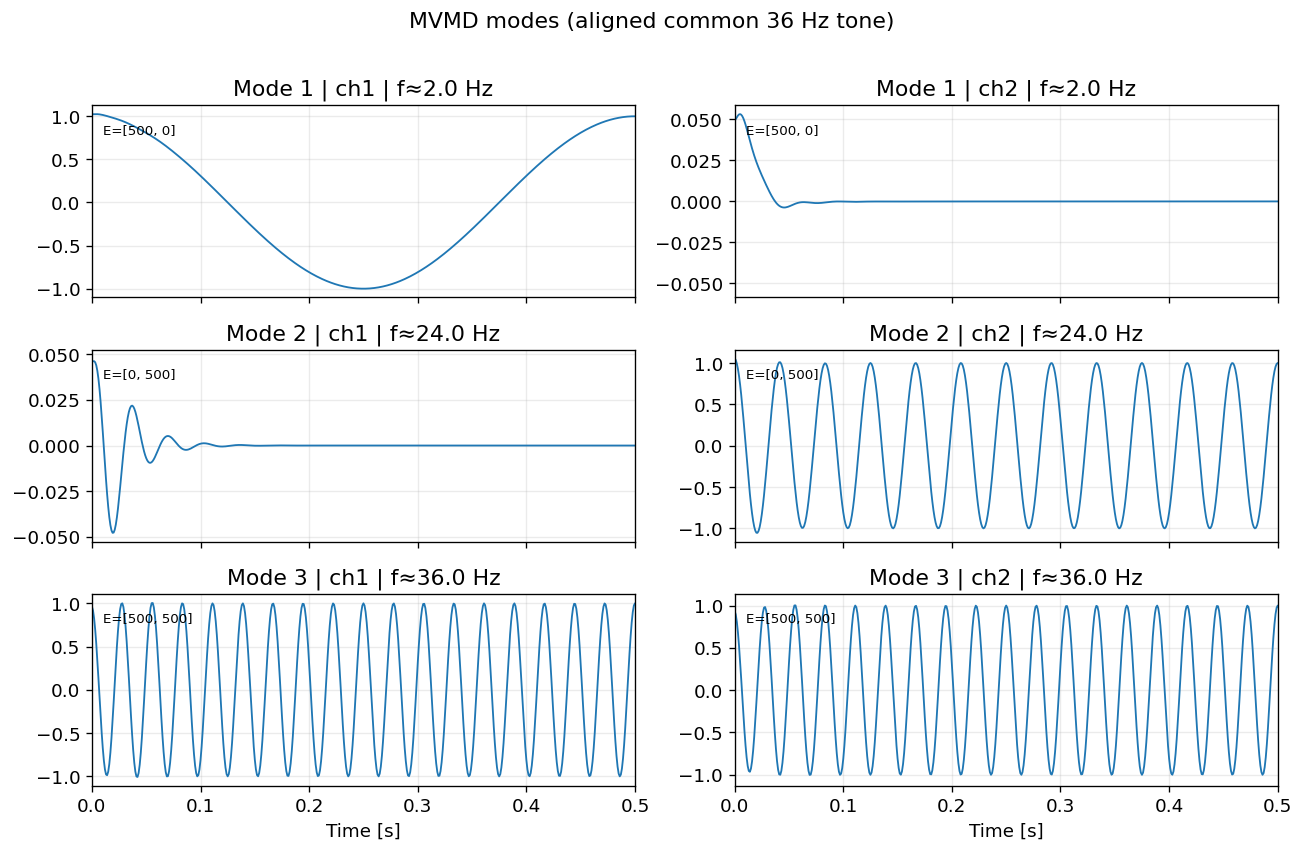

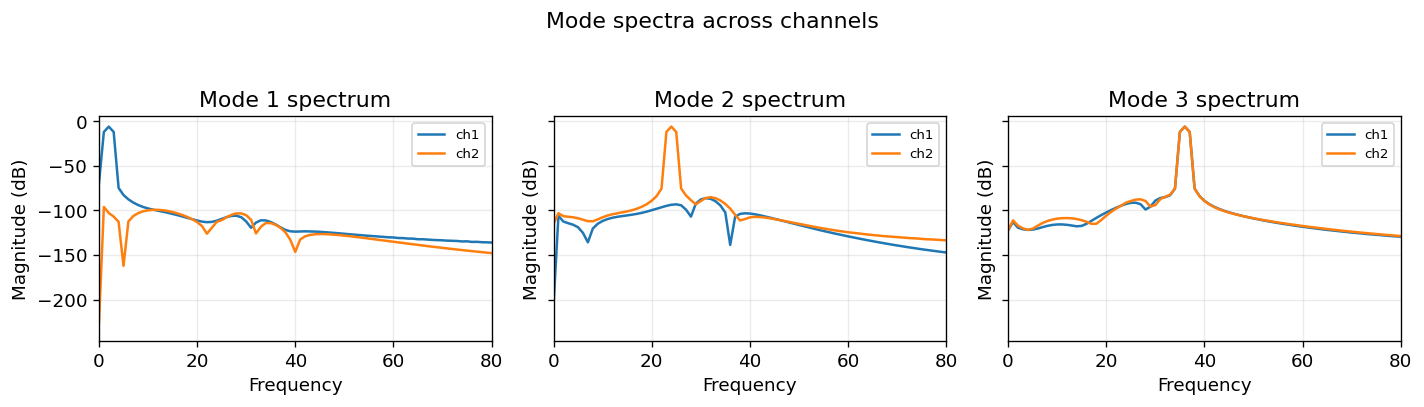

In [3]:
fs = 1000.0
t = np.arange(0, 1.0, 1.0 / fs)
true_2 = np.cos(2 * np.pi * 2 * t)
true_24 = np.cos(2 * np.pi * 24 * t)
true_36 = np.cos(2 * np.pi * 36 * t)

ch1 = true_2 + true_36
ch2 = true_24 + true_36
signal = np.vstack([ch1, ch2])

mvmd = MVMD(alpha=2000, K=3, tau=0.0, init="uniform", tol=1e-7, max_iter=500)
modes, u_hat, omega = mvmd.fit_transform(signal, return_all=True)

omega_hz = np.asarray(omega[-1], dtype=float).real * fs
order = np.argsort(omega_hz)
modes = modes[order]
omega_hz = omega_hz[order]

print("Estimated center frequencies [Hz]:", np.round(omega_hz, 2))
print("Expected: ~[2, 24, 36]")

fig, axs = plt.subplots(3, 2, figsize=(11, 7), sharex=True)
for k in range(3):
    for c in range(2):
        axs[k, c].plot(t, modes[k, :, c], lw=1.1)
        axs[k, c].set_title(f"Mode {k+1} | ch{c+1} | f≈{omega_hz[k]:.1f} Hz")
        e = mode_energies(modes[k])
        axs[k, c].text(
            0.02,
            0.85,
            f"E=[{e[0]:.0f}, {e[1]:.0f}]",
            transform=axs[k, c].transAxes,
            fontsize=8,
        )
    axs[k, 0].set_xlim(0, 0.5)
axs[-1, 0].set_xlabel("Time [s]")
axs[-1, 1].set_xlabel("Time [s]")
fig.suptitle("MVMD modes (aligned common 36 Hz tone)", y=1.01)
plt.tight_layout()
plt.show()

# Spectral view
fig, axs = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
for k in range(3):
    for c in range(2):
        axs[k].magnitude_spectrum(modes[k, :, c], Fs=fs, scale="dB", label=f"ch{c+1}")
    axs[k].set_xlim(0, 80)
    axs[k].set_title(f"Mode {k+1} spectrum")
    axs[k].legend(fontsize=8)
plt.suptitle("Mode spectra across channels", y=1.05)
plt.tight_layout()
plt.show()

## 7. Experiment 2: Channel-wise VMD vs joint MVMD

Paper Fig. 2(b): applying univariate VMD independently to each channel does **not** produce multivariate modes with a shared center frequency. In the paper, mode $u_2$ mixes **36 Hz on channel 1** with **24 Hz on channel 2** — a textbook case of mode misalignment.

We keep each channel’s **native VMD mode order** (no post-hoc frequency sorting), then contrast it with MVMD, where every mode has a single $\omega_k$ shared by all channels.


Channel-wise VMD center frequencies [Hz] (native order):
  ch1: [ 2.   36.   35.99]
  ch2: [24.   36.   23.99]
MVMD center frequencies [Hz] (sorted for display): [ 2. 24. 36.]


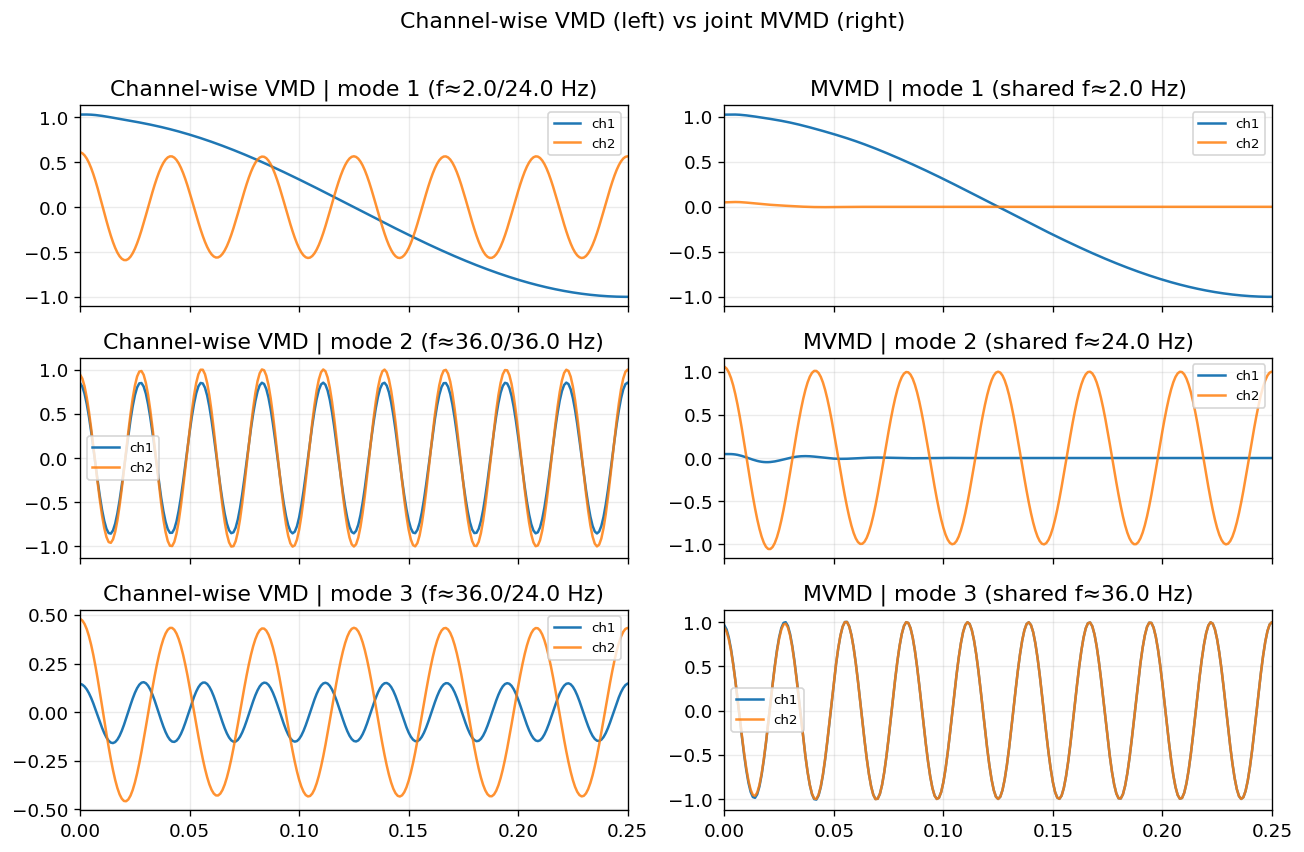


Per-mode frequency match (channel-wise VMD):
  mode 1: ch1=2.00 Hz, ch2=24.00 Hz, |Δ|=22.00 Hz
  mode 2: ch1=36.00 Hz, ch2=36.00 Hz, |Δ|=0.00 Hz
  mode 3: ch1=35.99 Hz, ch2=23.99 Hz, |Δ|=12.00 Hz
Per-mode shared frequency (MVMD):
  mode 1: ω=2.00 Hz (one value for all channels)
  mode 2: ω=24.00 Hz (one value for all channels)
  mode 3: ω=36.00 Hz (one value for all channels)


In [4]:
def channelwise_vmd(signal, alpha=2000, K=3, tau=0.0, max_iter=500, init="zero"):
    # Run univariate VMD on each channel; keep native mode order (no sorting).
    C, T = signal.shape
    out = np.zeros((K, T, C))
    omegas = []
    for c in range(C):
        vmd = VMD(alpha=alpha, K=K, tau=tau, tol=1e-7, max_iter=max_iter, init=init)
        u, _, om = vmd.fit_transform(signal[c], return_all=True)
        L = min(T, u.shape[1])
        out[:, :L, c] = u[:, :L]
        omegas.append(np.asarray(om[-1], dtype=float).real)
    return out, np.asarray(omegas)


vmd_modes, vmd_omegas = channelwise_vmd(signal)
print("Channel-wise VMD center frequencies [Hz] (native order):")
print("  ch1:", np.round(vmd_omegas[0] * fs, 2))
print("  ch2:", np.round(vmd_omegas[1] * fs, 2))
print("MVMD center frequencies [Hz] (sorted for display):", np.round(omega_hz, 2))

fig, axs = plt.subplots(3, 2, figsize=(11, 7), sharex=True)
for k in range(3):
    axs[k, 0].plot(t, vmd_modes[k, :, 0], label="ch1")
    axs[k, 0].plot(t, vmd_modes[k, :, 1], label="ch2", alpha=0.85)
    f1, f2 = vmd_omegas[0, k] * fs, vmd_omegas[1, k] * fs
    axs[k, 0].set_title(f"Channel-wise VMD | mode {k+1} (f≈{f1:.1f}/{f2:.1f} Hz)")
    axs[k, 0].legend(fontsize=8)

    axs[k, 1].plot(t, modes[k, :, 0], label="ch1")
    axs[k, 1].plot(t, modes[k, :, 1], label="ch2", alpha=0.85)
    axs[k, 1].set_title(f"MVMD | mode {k+1} (shared f≈{omega_hz[k]:.1f} Hz)")
    axs[k, 1].legend(fontsize=8)
    axs[k, 0].set_xlim(0, 0.25)
    axs[k, 1].set_xlim(0, 0.25)

fig.suptitle("Channel-wise VMD (left) vs joint MVMD (right)", y=1.01)
plt.tight_layout()
plt.show()

# Highlight the paper's point: for each mode index, do the two channels share a frequency?
print("\nPer-mode frequency match (channel-wise VMD):")
for k in range(3):
    f1, f2 = vmd_omegas[0, k] * fs, vmd_omegas[1, k] * fs
    print(f"  mode {k+1}: ch1={f1:.2f} Hz, ch2={f2:.2f} Hz, |Δ|={abs(f1-f2):.2f} Hz")
print("Per-mode shared frequency (MVMD):")
for k in range(3):
    print(f"  mode {k+1}: ω={omega_hz[k]:.2f} Hz (one value for all channels)")

## 8. Experiment 3: Noise robustness of mode alignment

Paper Section VII-E / Fig. 5: a bivariate mixture with unbalanced noise. With $\tau=0$, MVMD should still recover the shared tones in aligned modes.

We use a slightly simplified but equivalent setup:

- Shared tones at **2 Hz** and **80 Hz** (high-frequency tone kept well below Nyquist for stability);
- **24 Hz** present only in channel 2;
- Unbalanced Gaussian noise on the two channels.


Approx. SNR: ch1=9.9 dB, ch2=16.7 dB
Noisy MVMD center frequencies [Hz]: [  4.95  79.9  328.7 ]


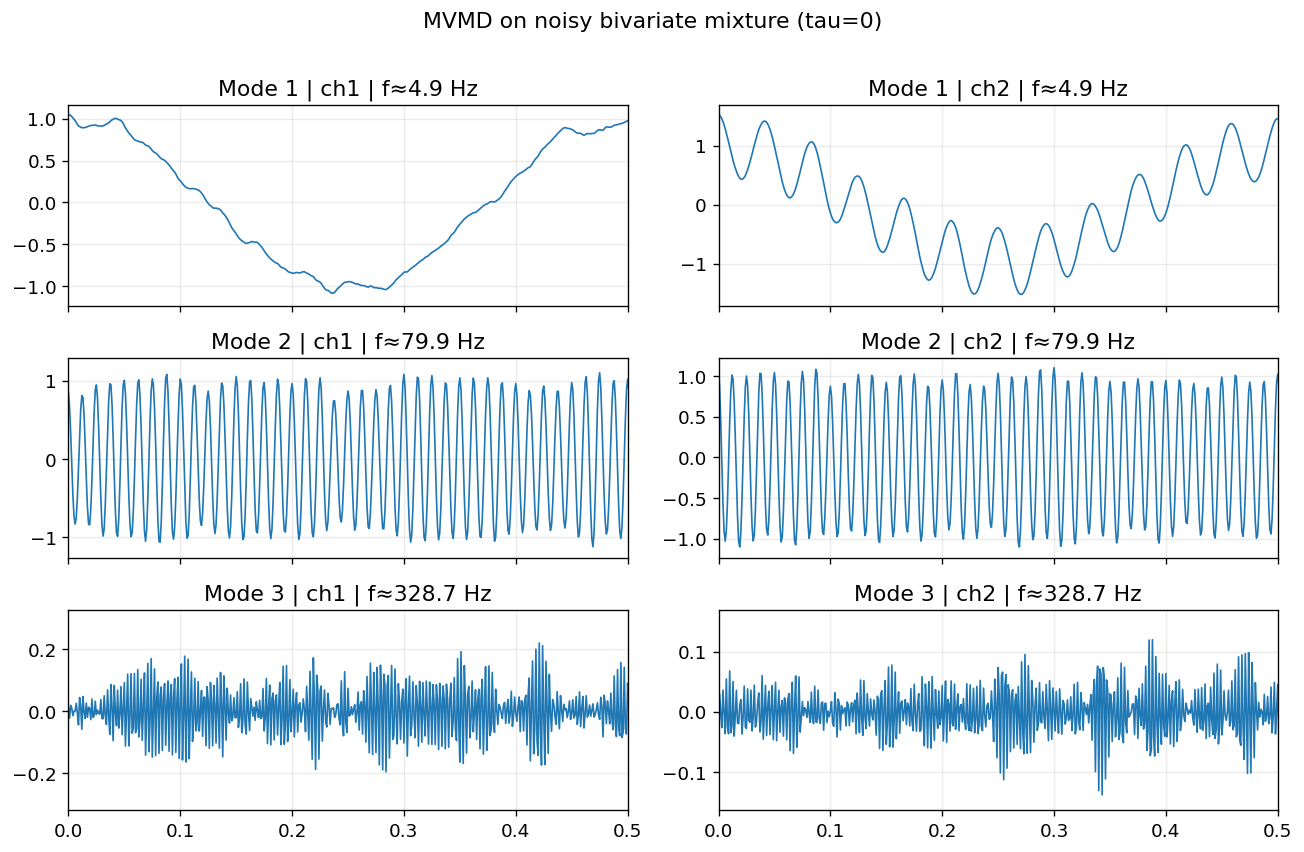

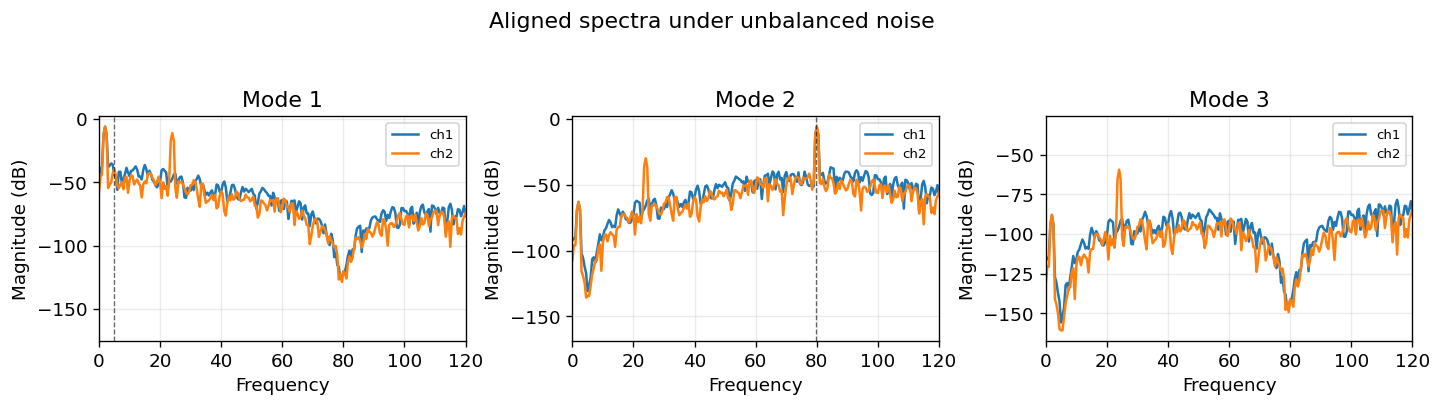

In [5]:
fs = 1000.0
t = np.arange(0, 2.0, 1.0 / fs)
rng = np.random.default_rng(0)

tone_2 = np.cos(2 * np.pi * 2 * t)
tone_24 = np.cos(2 * np.pi * 24 * t)
tone_80 = np.cos(2 * np.pi * 80 * t)

ch1 = tone_2 + tone_80 + 0.32 * rng.standard_normal(t.size)  # noisier
ch2 = tone_2 + tone_24 + tone_80 + 0.18 * rng.standard_normal(t.size)
noisy = np.vstack([ch1, ch2])

snr1 = 10 * np.log10(np.var(tone_2 + tone_80) / np.var(ch1 - (tone_2 + tone_80)))
snr2 = 10 * np.log10(
    np.var(tone_2 + tone_24 + tone_80) / np.var(ch2 - (tone_2 + tone_24 + tone_80))
)
print(f"Approx. SNR: ch1={snr1:.1f} dB, ch2={snr2:.1f} dB")

mvmd_n = MVMD(alpha=2000, K=3, tau=0.0, init="uniform", tol=1e-7, max_iter=500)
modes_n, _, omega_n = mvmd_n.fit_transform(noisy, return_all=True)
omega_n_hz = np.asarray(omega_n[-1], dtype=float).real * fs
order = np.argsort(omega_n_hz)
modes_n = modes_n[order]
omega_n_hz = omega_n_hz[order]
print("Noisy MVMD center frequencies [Hz]:", np.round(omega_n_hz, 2))

fig, axs = plt.subplots(3, 2, figsize=(11, 7), sharex=True)
for k in range(3):
    for c in range(2):
        axs[k, c].plot(t, modes_n[k, :, c], lw=1.0)
        axs[k, c].set_title(f"Mode {k+1} | ch{c+1} | f≈{omega_n_hz[k]:.1f} Hz")
    axs[k, 0].set_xlim(0, 0.5)
fig.suptitle("MVMD on noisy bivariate mixture (tau=0)", y=1.01)
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 3, figsize=(12, 3.2))
for k in range(3):
    for c in range(2):
        axs[k].magnitude_spectrum(modes_n[k, :, c], Fs=fs, scale="dB", label=f"ch{c+1}")
    axs[k].axvline(omega_n_hz[k], color="k", ls="--", lw=0.8, alpha=0.6)
    axs[k].set_xlim(0, 120)
    axs[k].set_title(f"Mode {k+1}")
    axs[k].legend(fontsize=8)
plt.suptitle("Aligned spectra under unbalanced noise", y=1.05)
plt.tight_layout()
plt.show()

## 9. Experiment 4: Quasi-orthogonality on white Gaussian noise

Paper Section VII-D / Fig. 4: for multichannel white Gaussian noise, MVMD modes are nearly orthogonal (correlation matrix almost diagonal).

We estimate a mode–mode correlation matrix by averaging absolute correlations across channels (a compact surrogate of the paper’s visualization).


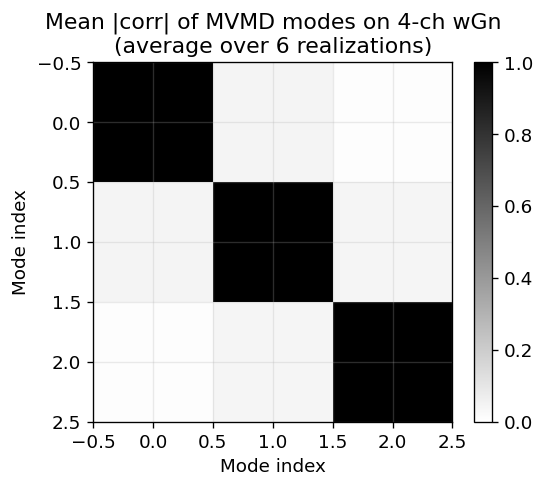

Mean off-diagonal |corr|: 0.021062140715205006
Max off-diagonal |corr|: 0.04438630483734111


In [8]:
def mode_corr_matrix(modes):
    # modes: (K, T, C) -> KxK matrix of mean |corr| across channels.
    K, T, C = modes.shape
    R = np.zeros((K, K))
    for c in range(C):
        X = modes[:, :, c]
        X = X - X.mean(axis=1, keepdims=True)
        # correlation matrix among K modes
        G = X @ X.T
        d = np.sqrt(np.diag(G))
        corr = G / np.outer(d + 1e-16, d + 1e-16)
        R += np.abs(corr)
    return R / C


C, T, K = 4, 512, 3
n_real = 6  # paper uses 100; keep moderate for notebook runtime
acc = np.zeros((K, K))
for i in range(n_real):
    rng = np.random.default_rng(i)
    wgn = rng.standard_normal((C, T))
    mvmd = MVMD(alpha=2000, K=K, tau=0.0, init="uniform", tol=1e-6, max_iter=200)
    u = mvmd.fit_transform(wgn)
    acc += mode_corr_matrix(u)
acc /= n_real

fig, ax = plt.subplots(figsize=(4.8, 4.2))
im = ax.imshow(acc, vmin=0, vmax=1, cmap="gray_r")
ax.set_title(
    f"Mean |corr| of MVMD modes on {C}-ch wGn\n(average over {n_real} realizations)"
)
ax.set_xlabel("Mode index")
ax.set_ylabel("Mode index")
fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

off = acc.copy()
np.fill_diagonal(off, 0.0)
print("Mean off-diagonal |corr|:", off.mean())
print("Max off-diagonal |corr|:", off.max())

## 10. Experiment 5: PySDKit multivariate test signals

PySDKit provides ready-made multivariate examples via `test_multivariate_signal`.

### Case 1 (2 channels)

- Channel 1: 5 Hz + 36 Hz
- Channel 2: 24 Hz + 36 Hz  
(shared 36 Hz component — the same alignment pattern as the paper)


Center frequencies [Hz]: [ 4.62 24.01 36.03]
Relative recon. error: 0.016913943006782773


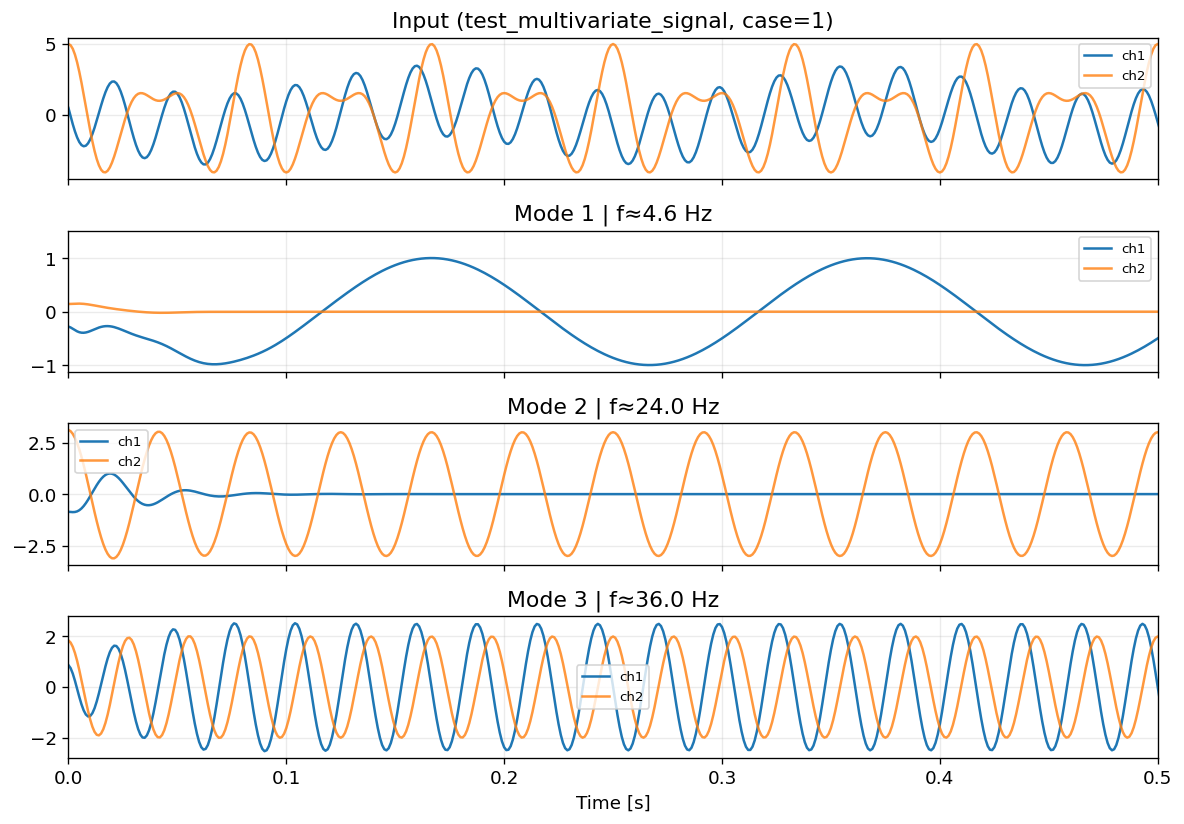

In [9]:
t, sig = test_multivariate_signal(case=1, duration=1.0, sampling_rate=1000)
fs = 1000.0

mvmd = MVMD(alpha=2000, K=3, tau=0.0, init="uniform", tol=1e-7, max_iter=500)
modes, _, omega = mvmd.fit_transform(sig, return_all=True)
omega_hz = np.asarray(omega[-1], dtype=float).real * fs
order = np.argsort(omega_hz)
modes = modes[order]
omega_hz = omega_hz[order]

print("Center frequencies [Hz]:", np.round(omega_hz, 2))
print("Relative recon. error:", relative_error(sig, modes.sum(0).T))

fig, axs = plt.subplots(4, 1, figsize=(10, 7), sharex=True)
axs[0].plot(t, sig[0], label="ch1")
axs[0].plot(t, sig[1], label="ch2", alpha=0.8)
axs[0].legend(fontsize=8)
axs[0].set_title("Input (test_multivariate_signal, case=1)")
for k in range(3):
    axs[k + 1].plot(t, modes[k, :, 0], label="ch1")
    axs[k + 1].plot(t, modes[k, :, 1], label="ch2", alpha=0.8)
    axs[k + 1].set_title(f"Mode {k+1} | f≈{omega_hz[k]:.1f} Hz")
    axs[k + 1].legend(fontsize=8)
axs[-1].set_xlim(0, 0.5)
axs[-1].set_xlabel("Time [s]")
plt.tight_layout()
plt.show()

4-channel input shape: (4, 1000)
Sorted center frequencies [Hz]: [  2.47  19.98  39.99 331.26]
Relative recon. error: 0.026012905920789264


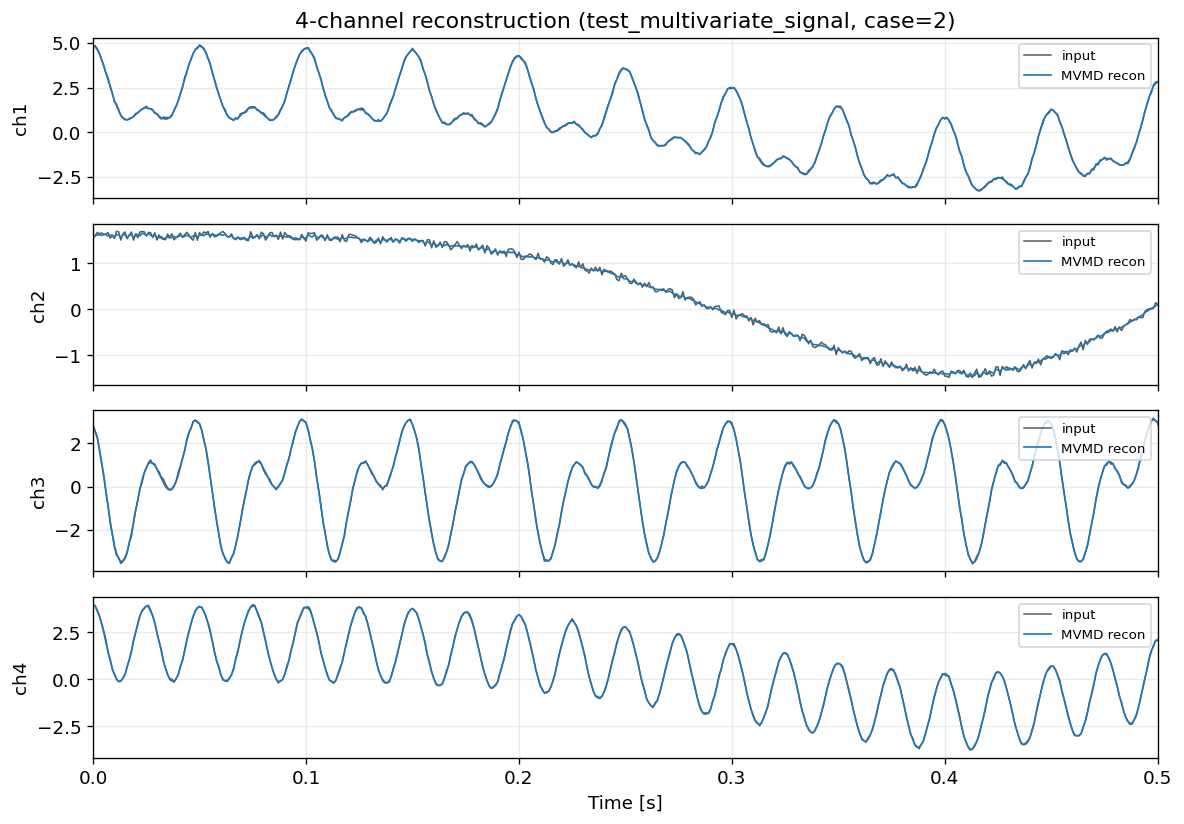

In [10]:
# Case 2: four channels with a common chirp-like component + tones + mild noise
t, sig4 = test_multivariate_signal(case=2, duration=1.0, sampling_rate=1000)
print("4-channel input shape:", sig4.shape)

mvmd4 = MVMD(alpha=2000, K=4, tau=0.0, init="uniform", tol=1e-7, max_iter=500)
modes4, _, omega4 = mvmd4.fit_transform(sig4, return_all=True)
omega4_hz = np.sort(np.asarray(omega4[-1], dtype=float).real * 1000.0)
print("Sorted center frequencies [Hz]:", np.round(omega4_hz, 2))
print("Relative recon. error:", relative_error(sig4, modes4.sum(0).T))

fig, axs = plt.subplots(sig4.shape[0], 1, figsize=(10, 7), sharex=True)
for c in range(sig4.shape[0]):
    axs[c].plot(t, sig4[c], color="0.35", lw=0.9, label="input")
    axs[c].plot(t, modes4.sum(0)[:, c], lw=1.0, label="MVMD recon")
    axs[c].set_ylabel(f"ch{c+1}")
    axs[c].legend(fontsize=8, loc="upper right")
axs[0].set_title("4-channel reconstruction (test_multivariate_signal, case=2)")
axs[-1].set_xlabel("Time [s]")
axs[-1].set_xlim(0, 0.5)
plt.tight_layout()
plt.show()

## 11. Summary

1. **Motivation**: Multichannel data need *mode-aligned* decompositions; channel-wise VMD and empirical MEMD are incomplete solutions.
2. **Model**: Multivariate modes share a **common center frequency** $\omega_k$; the cost is the sum of bandwidths over modes *and* channels.
3. **Algorithm**: ADMM in the Fourier domain — per-channel Wiener mode updates, **channel-pooled** center-frequency updates, dual ascent for $\lambda_c$.
4. **Key property demonstrated here**: mode alignment of shared tones (paper Fig. 2), robustness with $\tau=0$ under noise, and near-diagonal mode correlations on wGn.
5. **Practice**:
   - Input shape `(C, T)`; output modes `(K, T, C)`;
   - Choose $K$ from the expected number of joint oscillations;
   - Prefer $\tau=0$ for noisy recordings;
   - `init="uniform"` often helps when tones are well separated.

### Further reading

- ur Rehman & Aftab, *IEEE TSP*, 2019 (this paper — MVMD)
- Dragomiretskiy & Zosso, *IEEE TSP*, 2014 (univariate VMD)
- Rehman & Mandic, *IEEE Signal Process. Lett.* / related works on MEMD
- Jia et al., *Signal Processing*, 2026 (STVMD / short-time extensions)

### One-liner with PySDKit

    from pysdkit import MVMD
    modes = MVMD(alpha=2000, K=3, tau=0.0, init="uniform").fit_transform(signal)
